imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

configuration

In [2]:
INPUT_FILE  = Path("../../data/raw/icsa_affiliations.json")
OUTPUT_DIR  = Path("figures/isca")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Load & deduplicate

In [3]:
with open(INPUT_FILE) as f:
    raw = json.load(f)
 
df = (
    pd.DataFrame(raw)
    .dropna(subset=["country_code"])
    .drop_duplicates(subset=["doi", "year", "country_code"])
    .copy()
)
 
print(f"Loaded {len(df):,} deduplicated rows across {df.year.nunique()} years")

Loaded 626 deduplicated rows across 16 years


region mapping

In [4]:
REGION_MAP = {
    "AU": "Asia-Pacific", "NZ": "Asia-Pacific", "CN": "Asia-Pacific",
    "IN": "Asia-Pacific", "TH": "Asia-Pacific", "SG": "Asia-Pacific",
    "JP": "Asia-Pacific", "KR": "Asia-Pacific",
    "US": "North America", "CA": "North America", "MX": "North America",
    "DE": "Europe", "FR": "Europe", "GB": "Europe", "IT": "Europe",
    "ES": "Europe", "NL": "Europe", "SE": "Europe", "FI": "Europe",
    "DK": "Europe", "NO": "Europe", "AT": "Europe", "BE": "Europe",
    "CH": "Europe", "PL": "Europe", "PT": "Europe", "CZ": "Europe",
    "IE": "Europe", "HU": "Europe", "RO": "Europe", "SI": "Europe",
    "IS": "Europe", "LU": "Europe", "HR": "Europe", "TR": "Europe",
    "GR": "Europe",
    "BR": "Latin America", "AR": "Latin America", "CL": "Latin America",
    "CO": "Latin America", "MX": "Latin America",
    "TN": "Africa & Middle East", "DZ": "Africa & Middle East",
    "JO": "Africa & Middle East", "ZA": "Africa & Middle East",
    "EG": "Africa & Middle East",
}
 
REGION_ORDER = [
    "Europe",
    "North America",
    "Asia-Pacific",
    "Latin America",
    "Africa & Middle East",
    "Unknown",
]
 
REGION_COLORS = {
    "Europe":               "#3266ad",
    "North America":        "#e07b3a",
    "Asia-Pacific":         "#3aa66b",
    "Latin America":        "#b04db0",
    "Africa & Middle East": "#c0474a",
    "Unknown":              "#888780",
}
 
df["region"] = df["country_code"].map(REGION_MAP).fillna("Unknown")
 
# ── Build per-year region percentages ─────────────────────────────────────────
 
region_year = (
    df.groupby(["year", "region"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=REGION_ORDER, fill_value=0)
)
region_pct = region_year.div(region_year.sum(axis=1), axis=0) * 100
years = region_pct.index.tolist()

plot 1: line chart--regional share over time

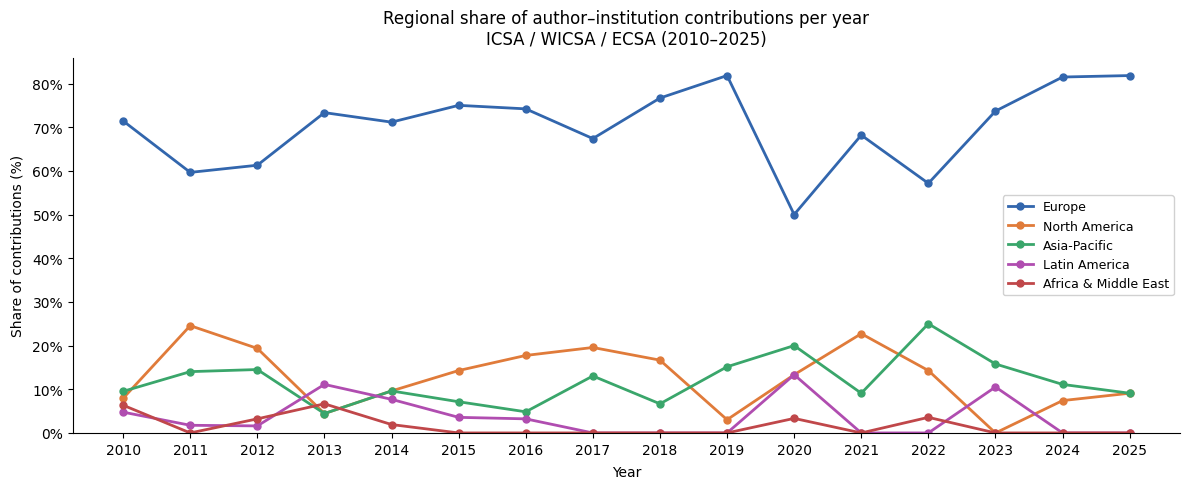

Saved → figures/isca_fig_region_line.png


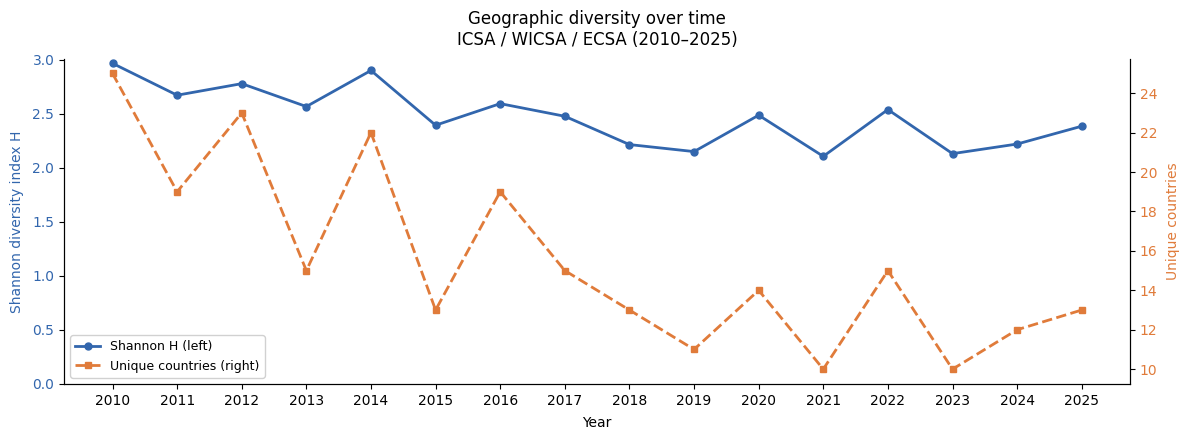

Saved → figures/isca_fig_diversity.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
 
for region in REGION_ORDER:
    if region not in region_pct.columns:
        continue
    vals = region_pct[region]
    if vals.max() < 1:
        continue  # skip regions with negligible presence
    ax.plot(
        years, vals,
        "o-",
        color=REGION_COLORS[region],
        linewidth=2,
        markersize=5,
        label=region,
    )
 
ax.set_xlabel("Year", labelpad=6)
ax.set_ylabel("Share of contributions (%)", labelpad=6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(years)
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="center right", fontsize=9, framealpha=0.9)
ax.set_title(
    "Regional share of author–institution contributions per year\n"
    "ICSA / WICSA / ECSA (2010–2025)",
    pad=10,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isca_fig_region_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/isca_fig_region_line.png")

 
# ── Plot 3: Shannon diversity index over time ──────────────────────────────────
 
def shannon(counts):
    s = pd.Series(counts)
    s = s[s > 0]
    p = s / s.sum()
    return float(-(p * np.log(p)).sum())
 
diversity = []
for year, g in df.groupby("year"):
    cc_counts = g["country_code"].value_counts()
    diversity.append({
        "year":        year,
        "shannon_H":   round(shannon(cc_counts), 3),
        "n_countries": g["country_code"].nunique(),
        "n_papers":    g["doi"].nunique(),
    })
 
div_df = pd.DataFrame(diversity).set_index("year")
 
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()
 
l1, = ax1.plot(div_df.index, div_df["shannon_H"], "o-",
               color="#3266ad", lw=2, ms=5, label="Shannon H (left)")
l2, = ax2.plot(div_df.index, div_df["n_countries"], "s--",
               color="#e07b3a", lw=2, ms=5, label="Unique countries (right)")
 
ax1.set_xlabel("Year", labelpad=6)
ax1.set_ylabel("Shannon diversity index H", color="#3266ad", labelpad=6)
ax2.set_ylabel("Unique countries", color="#e07b3a", labelpad=6)
ax1.tick_params(axis="y", labelcolor="#3266ad")
ax2.tick_params(axis="y", labelcolor="#e07b3a")
ax1.set_xticks(div_df.index)
ax1.set_ylim(bottom=0)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)
 
lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines],
           loc="lower left", fontsize=9, framealpha=0.9)
ax1.set_title("Geographic diversity over time\nICSA / WICSA / ECSA (2010–2025)", pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isca_fig_diversity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/isca_fig_diversity.png")

      shannon_H  H_max  evenness  n_countries  n_papers
year                                                   
2010      2.968  3.219     0.922           25        55
2011      2.673  2.944     0.908           19        44
2012      2.780  3.135     0.887           23        48
2013      2.568  2.708     0.948           15        34
2014      2.902  3.091     0.939           22        34
2015      2.395  2.565     0.934           13        19
2016      2.595  2.944     0.881           19        47
2017      2.478  2.708     0.915           15        34
2018      2.216  2.565     0.864           13        22
2019      2.151  2.398     0.897           11        22
2020      2.488  2.639     0.943           14        19
2021      2.107  2.303     0.915           10        15
2022      2.540  2.708     0.938           15        17
2023      2.132  2.303     0.926           10        15
2024      2.221  2.485     0.894           12        18
2025      2.386  2.565     0.930           13   

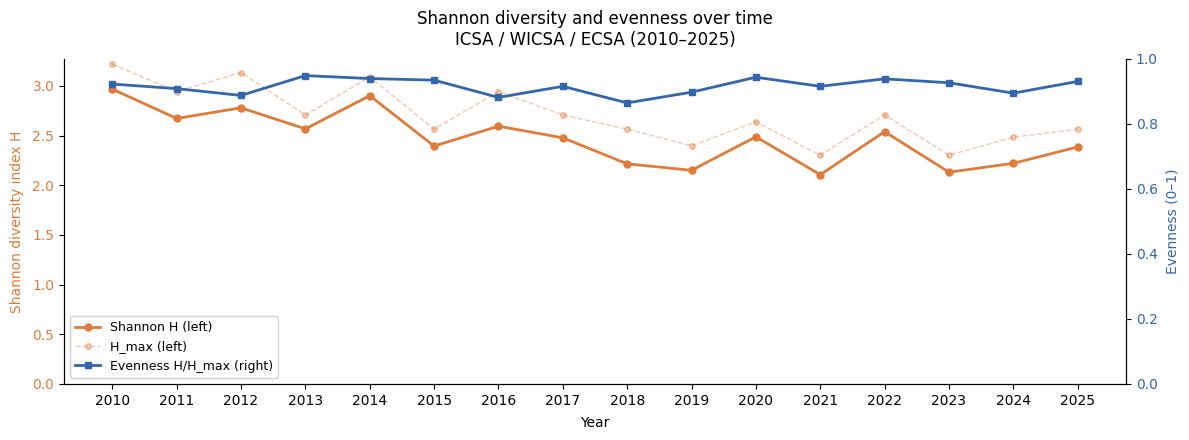

Saved → figures/isca_fig_evenness.png


In [6]:
# ── Shannon H and Evenness over time ──────────────────────────────────────────

import numpy as np

diversity = []
for year, g in df.groupby("year"):
    cc_counts = g["country_code"].value_counts()
    n = len(cc_counts)
    
    # Shannon H
    p = cc_counts / cc_counts.sum()
    H = float(-(p * np.log(p)).sum())
    
    # Evenness (H / H_max)
    H_max = np.log(n) if n > 1 else 1
    evenness = round(H / H_max, 3)
    
    diversity.append({
        "year":        year,
        "shannon_H":   round(H, 3),
        "H_max":       round(H_max, 3),
        "evenness":    evenness,
        "n_countries": n,
        "n_papers":    g["doi"].nunique(),
    })

div_df = pd.DataFrame(diversity).set_index("year")
print(div_df.to_string())

# ── Plot Shannon H and Evenness ────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()

l1, = ax1.plot(div_df.index, div_df["shannon_H"], "o-",
               color="#e07b3a", lw=2, ms=5, label="Shannon H (left)")
l2, = ax1.plot(div_df.index, div_df["H_max"], "o--",
               color="#e07b3a", lw=1, ms=4, alpha=0.4, label="H_max (left)")
l3, = ax2.plot(div_df.index, div_df["evenness"], "s-",
               color="#3266ad", lw=2, ms=5, label="Evenness H/H_max (right)")

ax1.set_xlabel("Year", labelpad=6)
ax1.set_ylabel("Shannon diversity index H", color="#e07b3a", labelpad=6)
ax2.set_ylabel("Evenness (0–1)", color="#3266ad", labelpad=6)
ax1.tick_params(axis="y", labelcolor="#e07b3a")
ax2.tick_params(axis="y", labelcolor="#3266ad")
ax2.set_ylim(0, 1)
ax1.set_xticks(div_df.index)
ax1.set_ylim(bottom=0)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

lines = [l1, l2, l3]
ax1.legend(lines, [l.get_label() for l in lines],
           loc="lower left", fontsize=9, framealpha=0.9)
ax1.set_title("Shannon diversity and evenness over time\nICSA / WICSA / ECSA (2010–2025)", pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isca_fig_evenness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/isca_fig_evenness.png")

using amy's region mapping to create a time series

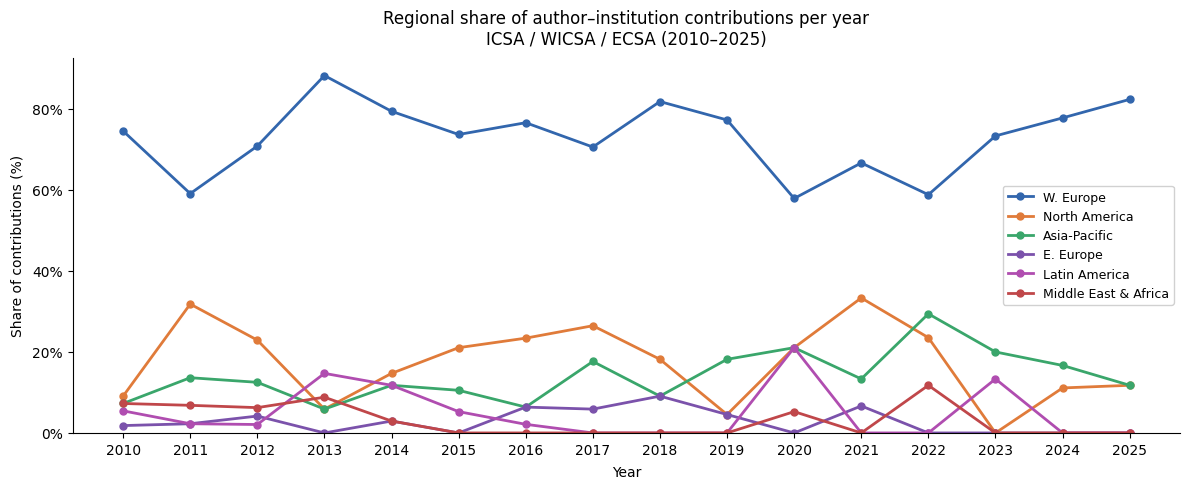

Saved → figures/isca_fig_region_line2.png


In [9]:
# ── Region order and colors matching teammate's mapping ────────────────────────

REGION_MAP = {
    "US": "North America", "CA": "North America", "MX": "North America",
    "BM": "North America", "GL": "North America",
    "DE": "W. Europe", "FR": "W. Europe", "GB": "W. Europe",
    "NL": "W. Europe", "IT": "W. Europe", "ES": "W. Europe",
    "SE": "W. Europe", "CH": "W. Europe", "AT": "W. Europe",
    "BE": "W. Europe", "FI": "W. Europe", "DK": "W. Europe",
    "NO": "W. Europe", "PT": "W. Europe", "IE": "W. Europe",
    "LU": "W. Europe", "GR": "W. Europe", "IS": "W. Europe",
    "MT": "W. Europe",
    "CZ": "E. Europe", "PL": "E. Europe", "HU": "E. Europe",
    "RO": "E. Europe", "SK": "E. Europe", "HR": "E. Europe",
    "RS": "E. Europe", "SI": "E. Europe", "BG": "E. Europe",
    "RU": "E. Europe", "EE": "E. Europe", "MK": "E. Europe",
    "CN": "Asia-Pacific", "JP": "Asia-Pacific", "AU": "Asia-Pacific",
    "KR": "Asia-Pacific", "SG": "Asia-Pacific", "HK": "Asia-Pacific",
    "TW": "Asia-Pacific", "IN": "Asia-Pacific", "NZ": "Asia-Pacific",
    "TH": "Asia-Pacific", "MY": "Asia-Pacific", "ID": "Asia-Pacific",
    "PK": "Asia-Pacific", "VN": "Asia-Pacific", "MO": "Asia-Pacific",
    "BR": "Latin America", "AR": "Latin America", "CL": "Latin America",
    "CO": "Latin America", "UY": "Latin America", "PE": "Latin America",
    "BB": "Latin America", "EC": "Latin America",
    "IL": "Middle East & Africa", "SA": "Middle East & Africa",
    "EG": "Middle East & Africa", "ZA": "Middle East & Africa",
    "IR": "Middle East & Africa", "AE": "Middle East & Africa",
    "TN": "Middle East & Africa", "DZ": "Middle East & Africa",
    "LY": "Middle East & Africa", "KW": "Middle East & Africa",
    "PS": "Middle East & Africa", "JO": "Middle East & Africa",
    "TR": "Middle East & Africa", "MA": "Middle East & Africa",
    "NA": "Middle East & Africa",
}

REGION_ORDER = [
    "W. Europe", "North America", "Asia-Pacific",
    "E. Europe", "Latin America", "Middle East & Africa", "Other"
]

REGION_COLORS = {
    "W. Europe":            "#3266ad",
    "North America":        "#e07b3a",
    "Asia-Pacific":         "#3aa66b",
    "E. Europe":            "#7b52ab",
    "Latin America":        "#b04db0",
    "Middle East & Africa": "#c0474a",
    "Other":                "#888780",
}

# ── Apply region mapping ───────────────────────────────────────────────────────

df["region"] = df["country_code"].map(REGION_MAP).fillna("Other")

# ── Build per-year region percentages ─────────────────────────────────────────

# deduplicate: one row per (doi, country_code) then map to region
# a paper can appear in multiple regions if it has authors from multiple regions
doi_region = (
    df.drop_duplicates(subset=["doi", "country_code"])
    .assign(region=lambda x: x["country_code"].map(REGION_MAP).fillna("Other"))
    .drop_duplicates(subset=["doi", "year", "region"])
)

region_year = (
    doi_region.groupby(["year", "region"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=REGION_ORDER, fill_value=0)
)
year_totals = doi_region.drop_duplicates(subset=["doi", "year"]).groupby("year").size()
region_pct = region_year.div(year_totals, axis=0) * 100
years = region_pct.index.tolist()

# ── Plot: Line chart — regional share over time ────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

for region in REGION_ORDER:
    if region not in region_pct.columns:
        continue
    vals = region_pct[region]
    if vals.max() < 1:
        continue
    ax.plot(
        years, vals,
        "o-",
        color=REGION_COLORS[region],
        linewidth=2,
        markersize=5,
        label=region,
    )

ax.set_xlabel("Year", labelpad=6)
ax.set_ylabel("Share of contributions (%)", labelpad=6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(years)
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="center right", fontsize=9, framealpha=0.9)
ax.set_title(
    "Regional share of author–institution contributions per year\n"
    "ICSA / WICSA / ECSA (2010–2025)",
    pad=10,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "isca_fig_region_line2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/isca_fig_region_line2.png")